# Preliminary Analysis — the labelled dataset, index order

This notebook follows the annotated index of the *Preliminary Analysis* document section by
section (1.1 → 5.5, then the additions). Each section is a markdown cell with the index's three
lines — **Source**, **Tables / figures**, **Gives →** — followed by the code that produces exactly
those tables and figures. The index text lives in `src/dataset_facts/index.py`; the notebook, the
block diagrams and the generated draft all read it from there.

The document states numbers; this notebook is where they come from. Change the labels, re-run
`Patent-Labelling-Tools/notebooks/04_master_labels.ipynb`, re-run this, and every table, figure and
the draft `PRELIMINARY_ANALYSIS.md` move with the data.

Thin notebook: it only **imports**, **calls** `src/dataset_facts/`, and **displays**.

> Unit of analysis, stated once at first use (1.3): the primary approved aircraft variant (805) for design statistics; the patent (695 approved primary) for metadata and citation statistics.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src.dataset_facts import (load_dataset, a1, a2, a3, a4, a5, a6, roster, rules, index,
                               figures, report, published, export)

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 250)

cfg = load_config()
F = cfg['dataset_facts']
OUT = ROOT / F['output_dir']
PARTIAL = F.get('partial_window_start', 2024)
ds = load_dataset(cfg)

print(ds.root)
ds.counts

/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_LABELLED


{'patents_acquired': 1639,
 'patents_approved': 1110,
 'patents_analysis': 695,
 'approved_variants': 1268,
 'primary_approved_variants': 805,
 'approved_figures': 1913}

The analysis unit is the **primary approved variant** (`ds.variants`, one row per aircraft, D1/D2
duplicates excluded). Patent-level facts use `ds.patents` (all 1,639) or `ds.patents_analysis` (the
approved primary 695). The labelling batches are provenance only — nothing is split by batch.

In [2]:
{k: v.shape for k, v in {
    'master (patent, variant)': ds.master,
    'approved variants': ds.approved_variants,
    'variants — the analysis unit': ds.variants,
    'patents': ds.patents,
    'patents in the analysis set': ds.patents_analysis,
    'approved figures': ds.approved_figures,
    'identity (Stage 03a)': ds.identity,
}.items()}

{'master (patent, variant)': (1797, 435),
 'approved variants': (1268, 435),
 'variants — the analysis unit': (805, 435),
 'patents': (1639, 435),
 'patents in the analysis set': (695, 435),
 'approved figures': (1913, 25),
 'identity (Stage 03a)': (1639, 164)}

---
## Overview — what each section gives, and which chapter it feeds

The block diagram is drawn from `index.py`: one box per section with its short *Gives* line,
arrows to the chapters it feeds.

,section,title,gives,feeds
0,1.1,Acquisition funnel,size of the set at each level; region reported everywhere,Ch. 3 Dataset · Ch. 4 Provenance
1,1.2,Filing reasons and inclusion gates,"the domain boundary, by rule",Ch. 3 Dataset
2,1.3,"Unit of analysis: unique aircraft, repeated observations, several aircraft per patent",how many independent aircraft; the unit decision,Ch. 4 Variety · Ch. 5 Evolution
3,1.4,Missingness and weak labels: which aircraft enter the analysis,"the roster: every aircraft that enters, with its sensitivity flags",Ch. 4 Quality · Ch. 5 Evolution
4,1.5,Filing-to-publication lag and the right-censoring cut,trends end at 2023; 2024–26 drawn as partial,Ch. 3 Dataset · Ch. 5 Evolution
5,1.6,Publication timeline,"windows of 3–5 years, rarefied to n ≈ 40",Ch. 5 Evolution
6,2.1,Answerable slots at patent and image level,slots ≠ concepts; sparsity is structural,Ch. 4 Variety · Ch. 5 Evolution
7,2.2,Figure basis of each label,one whole-aircraft figure per patent; the single-figure flag,Ch. 4 Quality · Ch. 6 Model
8,3.1,"Region, assignee country, publication office",where the corpus comes from; region as a stratum,Ch. 4 Provenance
9,3.2,Who filed and how concentrated it is,half the corpus is not corporate; concentration is mild,Ch. 4 Provenance · Ch. 5 Evolution


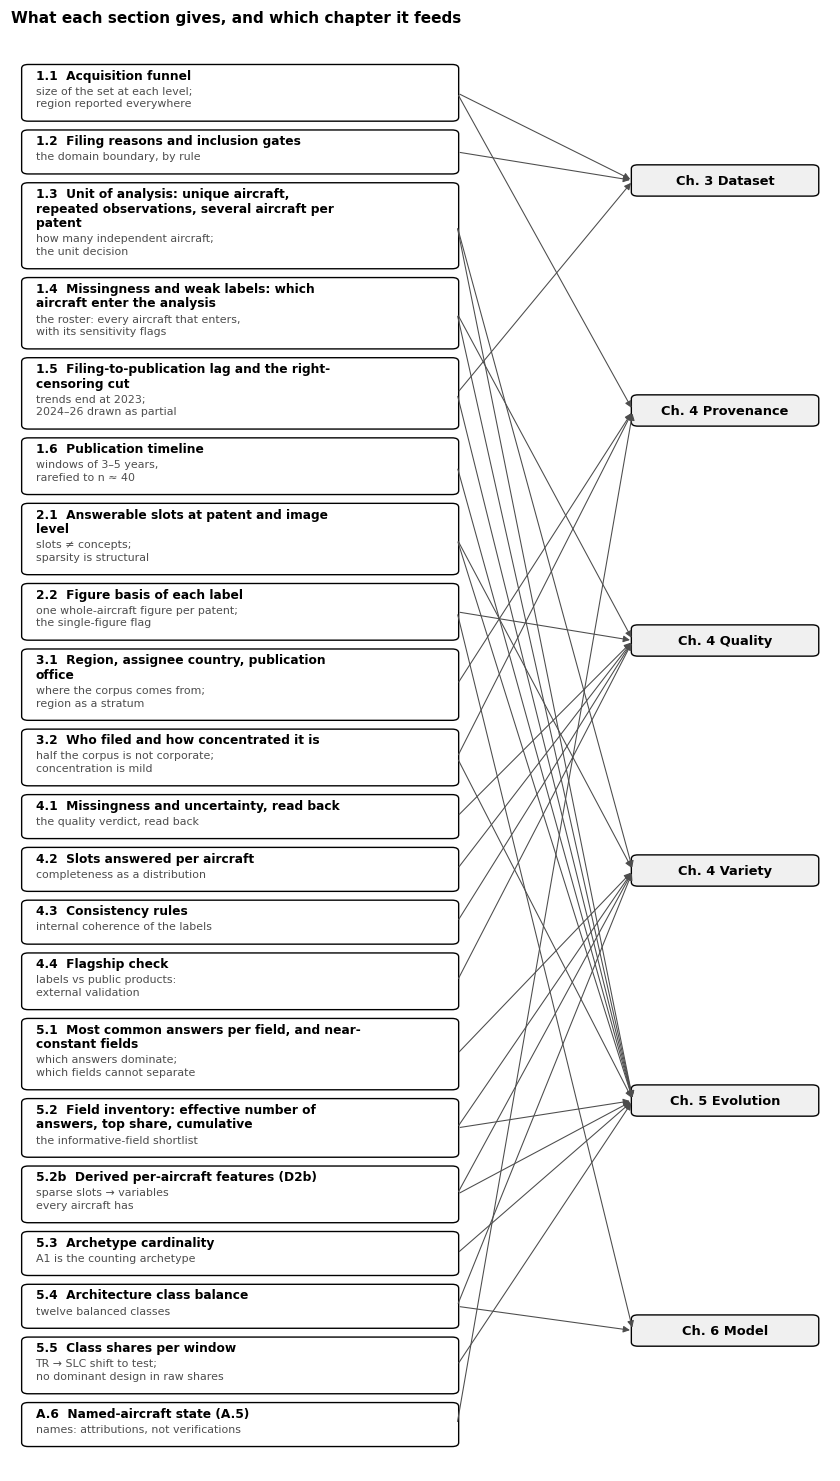

In [3]:
_ = figures.block_diagram([s['id'] for s in index.SECTIONS],
                          'What each section gives, and which chapter it feeds')
index.feeds_table()

---
## 1. Patent dataset construction (→ Ch. 3)

### 1.1 Acquisition funnel

- **Source**: D1 (funnel table); supervisor's pipeline figure with Table 1.
- **Tables / figures**: funnel figure 1,639 acquired → 1,110 approved → 695 primary patents → 1,268 variants → 805 primary variants → 1,913 approved figures. Rejection-reason table. Approval rate by region table. Rejection reasons by region and by filer type (addition 2).
- **Gives →** the size of the analysis set at each level and why two thirds survived; the regional approval gap shows the query behaves differently by office, so region is reported next to every later statistic. Feeds: Ch. 3 sample description; Ch. 4 Provenance (region as a possible confounder).

In [4]:
display(a2.d1_funnel(ds))
display(a2.d1_rejection_reasons(ds))
a2.d1_approval_by_region(ds)

,stage,count,note
0,Patents acquired (PatSeer query),1639,
1,Approved by the annotator,1110,68% of acquired
2,Approved patents that are the primary record,695,the analysis set of patents
3,Approved aircraft variants,1268,duplicates included
4,Primary approved variants - the analysis unit,805,one row per aircraft
5,Approved figures,1913,"on 729 patents, median 2 per patent"


,reason,patents
0,No Aircraft Image,173
1,Pure UAV,161
2,Out of Domain,158
3,Other,21
4,No Content,12
5,Not VTOL,3
6,(no reason recorded),1


,region,patents,approved,approval_rate
0,North America,719,558,0.78
1,Asia-Pacific,454,268,0.59
2,Europe,431,264,0.61
3,Middle East,20,8,0.40
4,South America,10,8,0.80
5,International (PCT),2,1,0.50
6,Unknown,2,2,1.00
7,Africa,1,1,1.00


Rejection reasons by region and by filer type (addition 2): whether the labelling filter behaves
the same across offices and applicants.

In [5]:
display(a2.d1_rejection_by_region(ds))
a2.d1_rejection_by_filer_type(ds)

region,Asia-Pacific,Europe,International (PCT),Middle East,North America,South America,all
reason,,,,,,,
(no reason recorded),1,0,0,0,0,0,1
No Aircraft Image,50,91,0,1,31,0,173
No Content,0,10,0,0,2,0,12
Not VTOL,1,0,0,0,2,0,3
Other,6,2,0,2,11,0,21
Out of Domain,55,43,0,0,59,1,158
Pure UAV,73,21,1,9,56,1,161
all,186,167,1,12,161,2,529


filer type,Individual inventor,Named company,Unattributed or independent,all
reason,,,,
(no reason recorded),0,0,1,1
No Aircraft Image,50,96,27,173
No Content,11,1,0,12
Not VTOL,2,0,1,3
Other,8,8,5,21
Out of Domain,62,53,43,158
Pure UAV,40,89,32,161
all,173,247,109,529


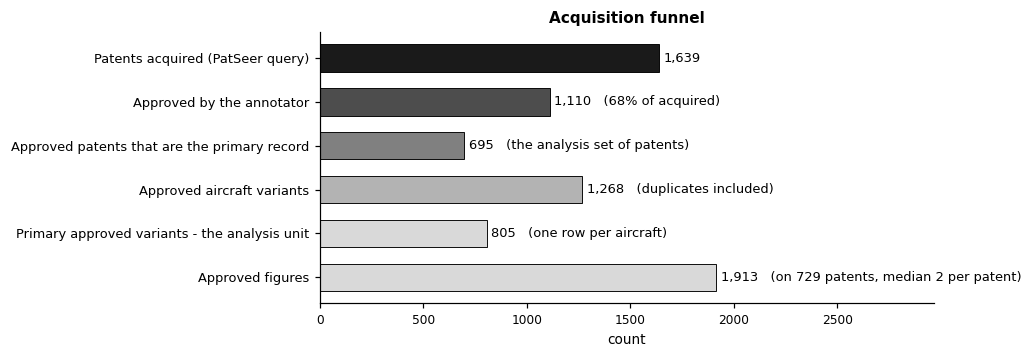

In [6]:
_ = figures.funnel(a2.d1_funnel(ds))

### 1.2 Filing reasons and inclusion gates

- **Source**: A.1 (electric / VTOL / UAV columns), Part B lines G1–G3, rejection reasons of D1.
- **Tables / figures**: one table with the three gates (electric, take-off, UAV) as the machine left them and the state after review (`*_final` columns).
- **Gives →** which patents are eVTOL by rule and which were excluded, so the domain boundary is explicit. Feeds: Ch. 3 technological domain definition; the V/STOL ruling.

`machine` is what Stage 03a decided; `after review` is the `*_final` column that carries the
annotator's decisions on top of it. The UAV hint and the UAV final use different vocabularies, so
they are listed side by side. First over all 1,639 patents, then over the 695 analysis patents.

In [7]:
display(a1.inclusion_gates(ds))
a1.inclusion_gates(ds, analysis_only=True)

,gate,value,machine,after review
0,electric,Hybrid,229,222
1,electric,No,70,56
2,electric,Unknown,464,514
3,electric,Yes,876,847
4,take-off,(blank),59,58
5,take-off,STOL,4,4
6,take-off,V/STOL,195,192
7,take-off,VTOL,1381,1385
8,UAV,(blank),1531,1589
9,UAV,UAV,70,0


,gate,value,machine,after review
0,electric,Hybrid,113,113
1,electric,No,28,28
2,electric,Unknown,193,193
3,electric,Yes,361,361
4,take-off,(blank),18,18
5,take-off,STOL,1,1
6,take-off,V/STOL,92,92
7,take-off,VTOL,584,584
8,UAV,(blank),639,652
9,UAV,UAV,36,0


### 1.3 Unit of analysis: unique aircraft, repeated observations, several aircraft per patent

- **Source**: D7 (duplicate types), aircraft-per-patent table, Part E.1.
- **Tables / figures**: duplicate table (D1 same aircraft new figures · D2 same aircraft same figures · D3 same invention modified, with the count identical to root at A1). Aircraft drawn per patent.
- **Gives →** how many independent aircraft there are and how the unit choice changes N; the double-count at A1 is stated with a number and kept as a sensitivity run. Feeds: every count in Ch. 4 and Ch. 5; the unit decision (G.4 #1).

In [8]:
display(a2.d7_duplicates(ds))
d3 = a2.d7_d3_identical_to_root(ds)
print(f"D3 identical to their root on all archetype fields: {d3['identical_on_all_archetype_fields']} "
      f"of {ds.counts['primary_approved_variants']} = {d3['share_of_analysis_set']:.1%} double-count at A1")
display(pd.Series(d3).to_frame('value'))
a2.d7_aircraft_per_patent(ds)

,duplicate type,what it is,rows,inside the analysis set
0,"D1 - same aircraft, new figures","labels inherited, not primary",38,0
1,"D2 - same aircraft, same figures","nothing relabelled, not primary",425,0
2,"D3 - same invention, modified","fully relabelled, primary",27,27


D3 identical to their root on all archetype fields: 15 of 805 = 1.9% double-count at A1


,value
d3_rows,27.000
same_architecture_as_root,26.000
identical_on_all_archetype_fields,15.000
share_of_analysis_set,0.019


,aircraft drawn in the patent,patents
0,1,627
1,2,44
2,3,12
3,4,8
4,5,2
5,6,2


### 1.4 Missingness and weak labels: which aircraft enter the analysis

- **Source**: D4 (structural missingness), D6 (uncertainty flags), D3 note on gearArch = Unknown.
- **Tables / figures**: conditional-fill table; one heatmap of fill rate conditional on parent. Flag table. Output of this section: the list of unique aircraft that enter, with their sensitivity flags (the roster).
- **Gives →** a blank is a labelling gap only where the parent says the part exists; on that test nearly every blank is design absence, so no aircraft is dropped for blanks. The three real gaps (wing height, planform, tail) are fixed or declared "not visible". Landing gear Unknown means not drawn, never absent. The flagged rows stay in, marked, and every analysis is run with and without them. Feeds: 1.5 and 1.6 operate on this list; Ch. 4 quality reads the numbers back; Gower δ treatment in Ch. 5.

In [9]:
display(a2.d4_missingness(ds))
a2.d6_weak_labels(ds)

,check,affected,of,share
0,Booms present but boom direction blank,0,365,0.000
1,Architecture type blank,3,805,0.004
2,Wings present but wing height blank,86,755,0.114
3,Wings present but wing planform blank,86,755,0.114
4,Wings present but tail type blank,30,755,0.040
5,Fuselage cross-section blank,28,805,0.035


,flag,column,aircraft
0,Mixed architecture,notPureArch,39
1,"Figure readability ""Impossible""",dinoUnderstanding,38
2,Annotator unsure at G1,g1_humanUncertain,35
3,Annotator unsure at M2,m2_humanUncertain,8
4,Annotator unsure at T1,t1_humanUncertain,5
5,Quick count override,g1_quickOverride,3
6,Annotator unsure at M1,m1_humanUncertain,2


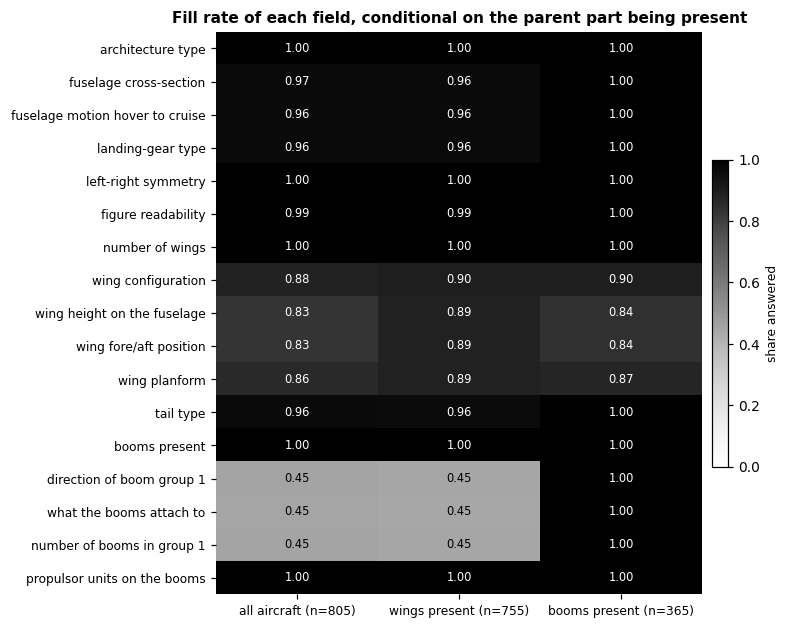

In [10]:
_ = figures.fill_rate_heatmap(ds)

**The roster** — the output of this section: every aircraft that enters, one row each, with every
sensitivity flag as a column. Nothing is dropped; each later analysis runs with and without the
flagged rows. Written to `outputs/preliminary_analysis/tables/roster.csv` by the export cell.

In [11]:
ROSTER = roster.analysis_set(ds, PARTIAL)
print(roster.counts(ROSTER))
display(roster.summary(ROSTER))
ROSTER.head()

{'aircraft_entering': 805, 'patents': 695, 'without_any_flag': 442, 'in_sensitivity_set': 253}


,flag,meaning,aircraft,share
0,single_figure,rests on one approved figure,226,0.281
1,quality_flagged,a figure of the patent is flagged partial or poor,11,0.014
2,readability_impossible,"figure readability ""Impossible""",38,0.047
3,in_sensitivity_set,any of the three above (the D11 thin-evidence flag),253,0.314
4,notPureArch,mixed architecture,39,0.048
5,g1_uncertain,annotator unsure at G1,35,0.043
6,m1_uncertain,annotator unsure at M1,2,0.002
7,m2_uncertain,annotator unsure at M2,8,0.010
8,t1_uncertain,annotator unsure at T1,5,0.006
9,quickOverride,quick count override (no architecture type by design),3,0.004


,patent_id,variant,topType,dup_type,priority_year,region,company_canonical,approved_figures,single_figure,quality_flagged,...,g1_uncertain,m1_uncertain,m2_uncertain,t1_uncertain,quickOverride,d3_duplicate,d3_identical_to_root,window_partial,in_sensitivity_set,any_flag
0,CN105923154A,1,SLC,NaN,2016,Asia-Pacific,Beihang University,1,True,False,...,False,False,False,False,False,False,False,False,True,True
1,EP3770063A1,1,MR,NaN,2019,Europe,Airbus,2,False,False,...,False,False,False,False,False,False,False,False,False,False
2,EP3770063A1,2,MR,NaN,2019,Europe,Airbus,1,True,False,...,False,False,False,False,False,False,False,False,True,True
3,FR3143549A1,1,SLC,NaN,2022,Europe,Ascendance Flight Technologies,3,False,False,...,False,False,False,False,False,False,False,False,False,False
4,US10450062B1,1,CVT,NaN,2017,North America,Amazon,3,False,False,...,False,False,False,False,False,False,False,False,False,False


### 1.5 Filing-to-publication lag and the right-censoring cut

- **Source**: D9 (lag table), Part E.2.
- **Tables / figures**: median and 90th-percentile lag by region and by office. Snapshot date.
- **Gives →** priority years to 2022 are complete, 2023 nearly, 2024–2026 truncated; every trend claim ends at 2023 and the last window is drawn as partial. This is what selects the patents that enter the G1–M3 analysis. Priority year is the time axis because it is the date closest to the design decision; application and publication years lag it by office-dependent amounts. Feeds: Ch. 3 corpus boundary; Ch. 5 window definition inherits the cut, does not re-derive it.

In [12]:
snapshot = ds.identity['snapshot_date'].dropna().iloc[0]
print(f'PatSeer snapshot: {snapshot}  ·  partial window starts at priority year {PARTIAL}')
display(a2.d9_publication_lag(ds, 'region'))
a2.d9_publication_lag(ds, 'pub_office')

PatSeer snapshot: 2026-06-08  ·  partial window starts at priority year 2024


,region,patents,median lag,90th percentile
0,North America,289,2.0,3.0
1,Asia-Pacific,199,1.0,3.0
2,Europe,191,2.0,3.0
3,South America,8,2.0,3.0
4,Middle East,4,2.0,4.0
5,Unknown,2,2.0,2.0
6,International (PCT),1,1.0,1.0
7,Africa,1,1.0,1.0


,pub_office,patents,median lag,90th percentile
0,US,409,2.0,3.0
1,CN,117,0.0,1.0
2,DE,38,1.0,2.0
3,WO,37,2.0,2.0
4,Other,29,1.0,2.0
5,EP,19,2.0,2.0
6,KR,16,2.0,2.0
7,GB,12,0.0,0.0
8,FR,11,2.0,2.0
9,IT,4,2.0,2.0


### 1.6 Publication timeline

- **Source**: A.1 time coverage, D9 counts.
- **Tables / figures**: patents per priority year, one bar chart; candidate windows with the variants each holds.
- **Gives →** per-year statistics before 2016 are noise, so windows of 3–5 years rarefied to n ≈ 40 are needed. Feeds: Ch. 5 window width and rarefaction n. Priority year is the time axis (closest to the design decision).

In [13]:
display(a1.time_coverage_summary(ds))
a2.d9_architecture_by_window(ds)[['window', 'variants']]

,era,years_present,patents,min_per_year,max_per_year
0,1999-2011,13,69,1,11
1,2012-2015,4,78,15,24
2,2016-2024,9,529,43,79
3,2025+,2,19,2,17


,window,variants
0,<= 2011,87
1,2012-15,94
2,2016-19,284
3,2020-23,276
4,2024-26 (partial),64


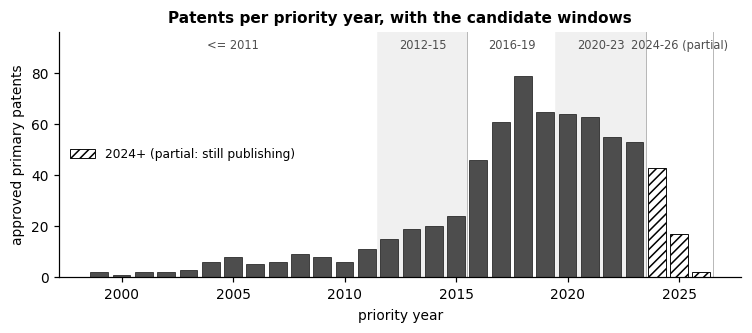

In [14]:
_ = figures.patents_per_year(a1.time_coverage(ds), partial_start=PARTIAL)

---
## 2. Image and labelling statistics (→ Ch. 3 labelling results; input to Ch. 6)

### 2.1 Answerable slots at patent and image level

- **Source**: D2 (label-set properties).
- **Tables / figures**: aircraft-level slot properties (slots, concepts, slots answered per aircraft, coverage, near-constant and informative counts); figure-level (T2) slots profiled over the approved figures.
- **Gives →** the 283 columns are slots, not concepts; sparsity is structural (boom groups, propulsor tiers), so absence is a design fact carried by the parent field. Feeds: the field shortlist for Ch. 4 and Ch. 5; the derived per-aircraft layer (D2b, see additions).

Aircraft level first (the cut-offs come from `config.yaml`), then the figure-level (T2) slots the
wizard answers on every approved figure — these describe the drawing, not the design, and are the
confounds the embedding pillar has to control for. *Assumption for "image level" in the index:*
the T2 slots; say so if another reading was meant.

In [15]:
display(a2.d2_label_set(
    ds,
    near_constant_min_answered=F.get('near_constant_min_answered', 100),
    near_constant_share=F.get('near_constant_share', 0.95),
    informative_min_answered=F.get('informative_min_answered', 300),
    informative_min_effk=F.get('informative_min_effective', 1.5),
))
a2.d2_figure_slots(ds)

,property of the label set,value
0,Answerable slots,283
1,Distinct concepts behind them (repeats collapsed),76
2,"Slots answered per aircraft, median",37
3,"Slots answered per aircraft, lower quartile",31
4,"Slots answered per aircraft, upper quartile",42
5,"Slots answered per aircraft, maximum",128
6,Slots answered on more than 90 % of aircraft,15
7,Slots answered on fewer than 5 % of aircraft,184
8,Fields with the same answer on 95% or more (answered on at least 100),15
9,Fields that carry the information,21


,name,field,answered,answers,top_share,effective_answers,most common answers
0,perspective,per,1912,7,0.49,4.1,Front-Isometric 930 · Top 383 · Side 319
1,drawing style,acSty,1912,3,0.95,1.2,Line Drawing 1825 · Render 77 · Draft 10
2,aircraft colour,acCol,1912,3,0.96,1.2,B/W (Monochrome) 1841 · Grayscale 64 · Full Color 7
3,background style,bgSty,1912,2,0.99,1.0,Solid Fill 1900 · Shaded/Gradient 12
4,what the figure shows,parts,1912,4,0.99,1.1,Whole Vehicle Layout 1891 · Tilt Hinge/Mechanism 12 · Rotor/Propeller Blade 5
5,quality flag,qualityFlag,1913,3,0.99,1.1,clean 1898 · generic 8 · poor_quality 7
6,flight state drawn,acState,1888,5,0.34,3.8,HoverCruise 650 · Hover 569 · Cruise 527
7,legends present,hasLegends,52,2,0.96,1.2,1.0 50 · 0.0 2


### 2.2 Figure basis of each label

- **Source**: D11.
- **Tables / figures**: approved figures per variant; figure quality; Whole Vehicle Layout share; median approved share per patent.
- **Gives →** every approved primary patent shows at least one whole aircraft (the inclusion criterion the labelling enforced); the variants that rest on one figure define the single-figure sensitivity flag. Feeds: Ch. 4 quality sensitivity runs; Ch. 6 dataset (whole-aircraft figures available to the frozen model).

In [16]:
display(a2.d11_figures_per_variant(ds))
display(a2.d11_figure_quality(ds))
a2.d11_sensitivity_set(ds)

,approved figures behind the aircraft,variants
0,1 figure,226
1,2 figures,319
2,3 figures,132
3,4 figures,84
4,5 or more,44


,approved figures,count
0,Clean,1898
1,Partial quality,8
2,Poor quality,7
3,Labelled Whole Vehicle Layout,1891
4,Total approved figures,1913


{'single_figure_variants': 226,
 'single_figure_share': 0.28,
 'median_approved_share_per_patent': 0.38,
 'sensitivity_set': 253,
 'patents_without_a_whole_vehicle_figure': 0}

---
## 3. Provenance (→ Ch. 4 Provenance)

### 3.1 Region, assignee country, publication office

- **Source**: A.1 metadata (region, assignee_country, pub_office), D1 by region.
- **Tables / figures**: region table; assignee-country table; publication-office table; one bar chart.
- **Gives →** where the corpus comes from and where the acquisition surplus sits (US whole-aircraft filings vs drone and component filings elsewhere). Feeds: Ch. 4 region as a stratum, never as a filter (G.4 #6).

In [17]:
prov = a1.provenance_tables(ds)
display(prov['region'])
display(prov['assignee_country'])
prov['pub_office']

,region,patents,approved,approval_rate
0,North America,719,558,0.78
1,Asia-Pacific,454,268,0.59
2,Europe,431,264,0.61
3,Middle East,20,8,0.40
4,South America,10,8,0.80
5,International (PCT),2,1,0.50
6,Unknown,2,2,1.00
7,Africa,1,1,1.00


,assignee_country,patents,approved,approval_rate
0,US,651,512,0.79
1,CN,267,153,0.57
2,DE,188,116,0.62
3,JP,95,68,0.72
4,KR,60,28,0.47
5,FR,58,29,0.50
6,GB,43,28,0.65
7,RU,40,19,0.48
8,IT,28,23,0.82
9,CA,26,20,0.77


,pub_office,patents,approved,approval_rate
0,US,1001,740,0.74
1,CN,241,139,0.58
2,DE,100,50,0.50
3,WO,85,57,0.67
4,Other,66,31,0.47
5,EP,39,34,0.87
6,KR,36,18,0.50
7,FR,29,15,0.52
8,GB,28,17,0.61
9,IT,8,5,0.62


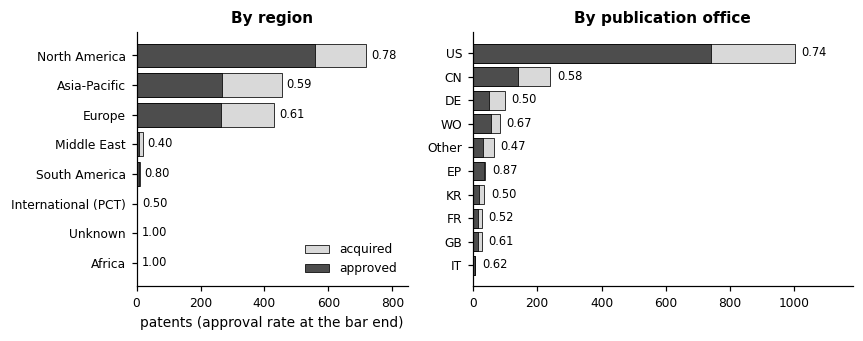

In [18]:
_ = figures.provenance_bars(prov['region'], prov['pub_office'])

### 3.2 Who filed and how concentrated it is

- **Source**: D8, plan line G8 (assignee type).
- **Tables / figures**: filer-type table; concentration table on raw string vs canonical company; single-patent filers; the strings one firm files under; Lorenz curve.
- **Gives →** half the corpus is not corporate, which is what makes the assignee-type stratum worth building; concentration is mild, so pseudo-replication matters mainly in the tilt-rotor class. Feeds: Ch. 4 Provenance (assignee type); Ch. 5 company bootstrap and within-company permutation. Still to produce: the `assignee_type` column (G8).

In [19]:
display(a2.d8_filer_mix(ds))
display(a2.d8_concentration(ds))
singles = a2.d8_single_patent_filers(ds)
display(singles)
print(singles.attrs)
a2.d8_split_firms(ds, 'Bell / Textron')

,filer,patents,share
0,Individual inventors,211,0.30
1,Unattributed or independent,152,0.22
2,Named companies (92 of them),332,0.48


,concentration measure,on the raw assignee string,on the canonical company
0,Distinct filers,449,94 values: 92 named companies plus the two catch-all buckets
1,Filers with exactly one patent,364,36 of the 92 named companies
2,Top-10 share of all 695 patents,0.18,0.22 (named companies only)
3,HHI,0.007,0.012 (named companies only)
4,Largest filer,"BELL HELICOPTER TEXTRON INC, 34","Bell / Textron, 66"


,value,count,share
0,Individual Inventor,172,0.47
1,Unknown / Independent,147,0.40
2,named company,45,0.12


{'distinct_named_companies': 42, 'examples': ['AMSL Innovations', 'Airbus', 'Alphabet / X', 'Anduril', 'Ascendance Flight Technologies', 'Aurora Flight Sciences']}


,assignee string,patents
0,BELL HELICOPTER TEXTRON INC,34
1,BELL TEXTRON INC,19
2,TEXTRON INNOVATIONS INC,10
3,TEXTRON SYSTEM CORP,2
4,AAI CORP,1


The `assignee_type` column (G8) does not exist yet; the suffix heuristic below only shows the size
of the prize and is not a variable to analyse.

In [20]:
a1.assignee_type(ds)

,value,count,share
0,company,1029,0.63
1,unresolved,541,0.33
2,university,69,0.04


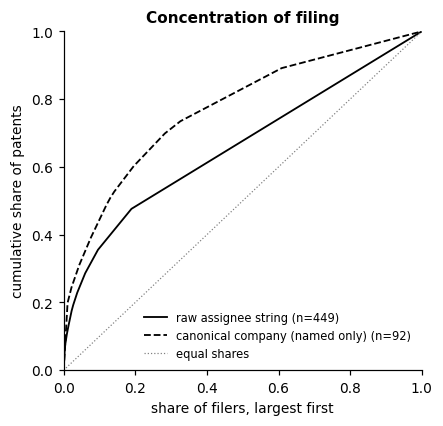

In [21]:
raw, canonical = a2.d8_filer_counts(ds)
_ = figures.lorenz(raw, canonical)

---
## 4. Label quality (→ Ch. 4 Quality of data and methods of certifying it)

### 4.1 Missingness and uncertainty, read back

- **Source**: sections 1.4 (D4, D6). No new table.
- **Tables / figures**: none; one paragraph pointing to 1.4.
- **Gives →** the quality verdict on the labels that entered: which fields carry declared gaps, how many rows are flagged, and the size of the sensitivity set. Feeds: reliability paragraph.

No new table: the D4 conditional-fill table, the D6 flag table and the roster summary of 1.4 are
the quality verdict on the labels that entered.

### 4.2 Slots answered per aircraft

- **Source**: D2.
- **Tables / figures**: median, quartiles, maximum; histogram.
- **Gives →** completeness of one label as a distribution, not a single number. Feeds: reliability paragraph.

,slots answered per aircraft
count,805.0
mean,36.8
std,10.5
min,13.0
25%,31.0
50%,37.0
75%,42.0
max,128.0


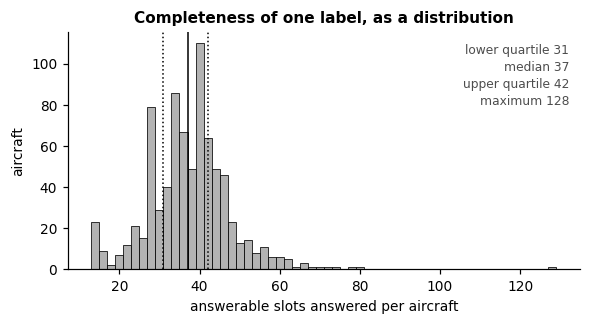

In [22]:
slots = a2.d2_slots_per_aircraft(ds)
display(slots.describe().round(1).to_frame('slots answered per aircraft'))
_ = figures.slots_histogram(slots)

### 4.3 Consistency rules

- **Source**: D12 (02a rule-violation counts before and after correction). Partial: only the batches 02a has been run on.
- **Tables / figures**: one table of rule applications and skips per batch.
- **Gives →** internal coherence of the labelling; reliability evidence that does not need a second annotator. Feeds: reliability paragraph.

Partial until 02a has been run on every batch: the table reads whatever `rule_decisions_*.json`
files the configured glob finds.

In [23]:
rc = rules.d12_rule_counts(F['rule_decisions_glob'])
print('batches found:', rc.attrs['batches'], '· partial:', rc.attrs['partial'])
display(rules.d12_by_rule(rc))
rc

batches found: ['Batch_01', 'Batch_05'] · partial: True


,rule,applied,skipped,batches
0,BC — boom<N>_count True/False → 1/0 (all batches),106,0,2
1,TR — topType TP → TR codebook rename (all batches),91,0,2
2,New — multi-architecture aircraftName_perArch suffix (Part C),58,0,2
3,D — Duplicate inheritance (topType/isApproved),33,0,2
4,A1 — Fixed-arch acState auto-set to HoverCruise (Bug-1 fix pt.1),32,6,2
5,C — UAVSimilar duplicate-chain propagation (Bug-2 fix: D3 excluded as destination),15,1,2
6,E — acState Ground → Other (Bug-1 fix pt.2: convertible-arch only),2,2,2
7,0 — Ghost-block cleanup,1,0,1


,rule,batch,applied,skipped,saved_utc
0,0 — Ghost-block cleanup,Batch_01,1,0,2026-08-31
1,A1 — Fixed-arch acState auto-set to HoverCruise (Bug-1 fix pt.1),Batch_01,22,2,2026-08-31
2,BC — boom<N>_count True/False → 1/0 (all batches),Batch_01,74,0,2026-08-31
3,C — UAVSimilar duplicate-chain propagation (Bug-2 fix: D3 excluded as destination),Batch_01,15,0,2026-08-31
4,D — Duplicate inheritance (topType/isApproved),Batch_01,32,0,2026-08-31
5,E — acState Ground → Other (Bug-1 fix pt.2: convertible-arch only),Batch_01,1,0,2026-08-31
6,New — multi-architecture aircraftName_perArch suffix (Part C),Batch_01,55,0,2026-08-31
7,TR — topType TP → TR codebook rename (all batches),Batch_01,54,0,2026-08-31
8,A1 — Fixed-arch acState auto-set to HoverCruise (Bug-1 fix pt.1),Batch_05,10,4,2026-08-31
9,BC — boom<N>_count True/False → 1/0 (all batches),Batch_05,32,0,2026-08-31


### 4.4 Flagship check

- **Source**: D13.
- **Tables / figures**: company × labels × public product × verdict.
- **Gives →** the labels agree with what the world knows where the answer is public; the disagreements are alternative embodiments, which is itself a sentence in the thesis. Feeds: external validation in Ch. 4; a short re-read list. Open: whether the intra-rater re-label (κ per field, 60–100 patents, 4 weeks after last labelling) enters as 4.5 or is a stated scope decision.

In [24]:
a2.d13_flagship_check(ds).head(20)

,company,aircraft,labels,distinct types,public products,public types differ,top label matches a public type
0,Bell / Textron,80,Tilt Rotor 42 · Combined vectored thrust 16 · Tilt Body 9 · Tilt Wing 7 · Multirotor 4,7,APT (TB) · Nexus (TR),True,True
1,Airbus,26,Lift + Cruise 17 · Multirotor 4 · Pitch-to-Cruise 3 · Tilt Rotor 2,4,CityAirbus (MR) · CityAirbus NextGen (SLC),True,True
2,Kitty Hawk,12,Multirotor 3 · Tilt Rotor 3 · Tilt Wing 3 · Lift + Cruise 2 · Stopped/Slowed Rotor Wing 1,5,Flyer (MR) · Heaviside (TR),True,True
3,Shenfeng Aviation,11,Lift + Cruise 5 · Combined vectored thrust 3 · Pitch-to-Cruise 1,3,,False,None
4,Boeing,10,Tilt Rotor 3 · Lift + Cruise 3 · Tilt Wing 1 · Multirotor 1 · Personal Flying Vehicle 1,6,Passenger Air Vehicle (SLC),False,False
5,Leonardo,10,Combined vectored thrust 6 · Tilt Rotor 4,2,,False,None
6,Porsche,9,Lift + Cruise 3 · Combined vectored thrust 2 · Pitch-to-Cruise 2 · Tilt Rotor 1 · Roto...,5,,False,None
7,Honda,9,Lift + Cruise 6 · Hoverbike 1 · Personal Flying Vehicle 1 · Multirotor 1,4,Honda eVTOL (SLC),False,True
8,KARI,8,Tilt Rotor 5 · Combined vectored thrust 2 · Lift + Cruise 1,3,,False,None
9,Lilium,8,Lift + Cruise 3 · Deflected Slipstream 2 · Tilt Rotor 2 · Combined vectored thrust 1,4,Lilium Jet (TR),False,False


---
## 5. Design-space descriptives (→ Ch. 4 Variety and Diversity; 5.5 → Ch. 5)

Opening figure: purpose of each subsection and the analysis it feeds.

,section,title,gives,feeds
0,5.1,"Most common answers per field, and near-constant fields",which answers dominate; which fields cannot separate,Ch. 4 Variety
1,5.2,"Field inventory: effective number of answers, top share, cumulative",the informative-field shortlist,Ch. 4 Variety · Ch. 5 Evolution
2,5.2b,Derived per-aircraft features (D2b),sparse slots → variables every aircraft has,Ch. 4 Variety · Ch. 5 Evolution
3,5.3,Archetype cardinality,A1 is the counting archetype,Ch. 5 Evolution
4,5.4,Architecture class balance,twelve balanced classes,Ch. 4 Variety · Ch. 6 Model
5,5.5,Class shares per window,TR → SLC shift to test; no dominant design in raw shares,Ch. 5 Evolution


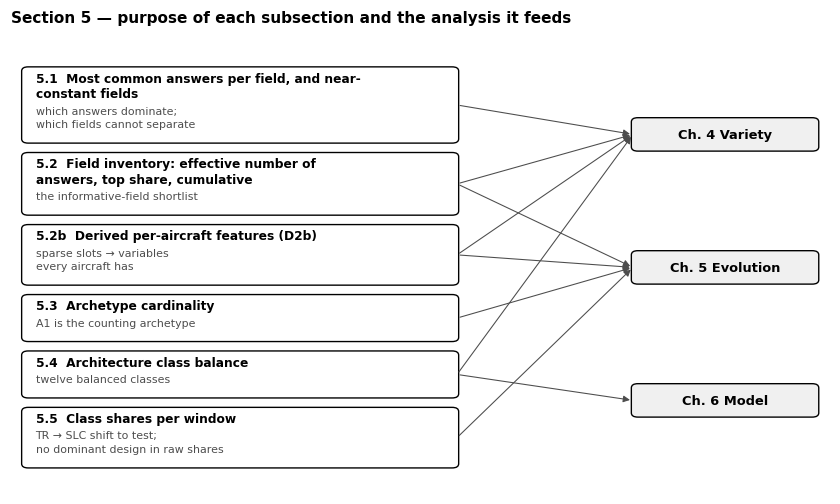

In [25]:
_ = figures.block_diagram([s['id'] for s in index.sections_of('5')],
                          'Section 5 — purpose of each subsection and the analysis it feeds')
index.feeds_table([s['id'] for s in index.sections_of('5')])

### 5.1 Most common answers per field, and near-constant fields

- **Source**: D3 second table, D2 (near-constant fields), A.3 group 2.
- **Tables / figures**: field × answered × answers × top share × most common answers. Separate list of the near-constant fields.
- **Gives →** which answers dominate and which fields cannot separate designs. Near-constant fields are reported as findings about the boundaries of the design space, then excluded from distances. Feeds: field shortlist; Ch. 4 descriptive statements.

In [26]:
display(a2.d3_selected_fields(ds))
a2.d2_near_constant_fields(
    ds,
    min_answered=F.get('near_constant_min_answered', 100),
    min_share=F.get('near_constant_share', 0.95),
)

,name,field,answered,answers,top_share,most common answers
0,number of wings,wCount,805,4,0.64,1.0 514 · 2.0 217 · 0.0 50 · 3.0 24
1,tail type,empType,774,13,0.29,Tailless (None) 223 · Conventional (Horizontal at base) 96 · V-Tail 74 · Single Vertic...
2,fuselage motion hover to cruise,fusKin,776,4,0.87,Fixed / Conventional 677 · Whole-Body Pitch 51 · Tail-sitter 35 · Variable Incidence 13
3,wing configuration,wingConf,710,6,0.88,Standard Wings 624 · Other 51 · Blended Wing Body 25 · Lifting Body 6
4,landing-gear type,gearArch,776,4,0.69,Unknown 532 · Skids / Fixed Skids 129 · Wheeled Gear 113 · Pads / Hull 2
5,left-right symmetry,latSym,805,2,0.96,1.0 769 · 0.0 36


,name,field,card,answered,answers,top_share,effective_answers
0,,wing1_role,M2,780,1,1.00,1.00
1,,emp_rmech,M3,119,1,1.00,1.00
2,,wing2_rmech,M3,126,2,0.99,1.05
3,,boom_sym,M3,804,2,0.98,1.11
4,,wing2_chord,M3,119,2,0.98,1.09
5,,wing1_rmech,M3,361,3,0.98,1.13
6,,empTilts,M2,805,2,0.98,1.10
7,,boom_t1_chord,M3,159,2,0.97,1.12
8,,boom_rmech,M3,142,3,0.96,1.22
9,,boom_t1_rmech,M3,179,3,0.96,1.21


### 5.2 Field inventory: effective number of answers, top share, cumulative

- **Source**: D2 ranked table (`phase1_field_inventory.csv`).
- **Tables / figures**: ranked table of the informative fields with card, answered, answers, top share, effective number, and the cumulative share of the top-2 and top-3 answers.
- **Gives →** which fields carry information; the shortlist for Gower, Cramér's V and archetypes chosen from evidence. Feeds: Ch. 4 Variety; Ch. 5 methods (Gower field list, weights).

*Assumption for "cumulative" in the index:* the cumulative share of the two and three most
common answers (`top2_cumulative`, `top3_cumulative`); say so if another reading was meant.

In [27]:
a2.d2_informative_fields(
    ds,
    min_answered=F.get('informative_min_answered', 300),
    min_effk=F.get('informative_min_effective', 1.5),
)

,name,field,card,answered,answers,top_share,effective_answers,top2_cumulative,top3_cumulative
0,tail type,empType,M2,774,13,0.29,8.8,0.41,0.51
1,architecture type,topType,G1,802,12,0.28,7.1,0.53,0.68
2,propulsor units on the booms,boom_count,M3,804,19,0.58,4.4,0.74,0.81
3,propulsors along the wing span,wing1_zoneSpan,M3,397,5,0.49,3.7,0.72,0.87
4,direction of boom group 1,boom1_orient,M1,365,5,0.62,3.1,0.79,0.90
5,wing height on the fuselage,wing1_posV,M2,669,4,0.58,3.0,0.81,0.91
6,fuselage cross-section,fusShape,M1,777,5,0.60,3.0,0.84,0.92
7,wing planform,wing1_plan,M2,694,5,0.63,2.6,0.90,0.96
8,propulsors along the wing chord,wing1_zoneChord,M3,400,4,0.69,2.5,0.83,0.95
9,number of wings,wCount,M2,805,4,0.64,2.5,0.91,0.97


### 5.2b Derived per-aircraft features (D2b)

- **Source**: A.3 group 1 (addition 1).
- **Tables / figures**: total propulsor units, any tilting, mixed fixed and tilting, any ducted, all ducted, thrust-axis mix, units per carrier. One table.
- **Gives →** the sparse boom and tier slots as variables every aircraft has. Feeds: Gower, Cramér's V, MCA.

In [28]:
display(a3.derived_layer_summary(ds))
a3.derived_layer(ds).head()

,derived variable,value
0,"Total propulsor units, median",4
1,"Total propulsor units, quartiles",3-8
2,Aircraft with more than 8 propulsor units,133
3,Aircraft with any tilting unit,296
4,Aircraft mixing fixed and tilting units,111
5,Aircraft with any ducted unit,250
6,Aircraft whose units are all ducted,148


,patent_id,variant,propulsor_units,any_tilting_unit,mixes_fixed_and_tilting,any_ducted_unit,all_units_ducted,thrust_axis_mix,propulsor_carriers,units_on_the_wing_span,units_on_the_wing_chord
0,CN105923154A,1,4.0,False,False,False,False,True,3,Wingtip,TE
1,EP3770063A1,1,4.0,False,False,True,True,False,1,NaN,NaN
2,EP3770063A1,2,6.0,False,False,True,True,False,1,NaN,NaN
3,FR3143549A1,1,8.0,False,False,True,False,True,4,Inboard,Below
4,US10450062B1,1,6.0,True,True,False,False,True,2,NaN,NaN


### 5.3 Archetype cardinality

- **Source**: D5.
- **Tables / figures**: level × fields × distinct × singletons × effective number.
- **Gives →** how fine a design species can be before every patent is its own kind; A1 (three fields) is the counting archetype, finer levels enter only through distances. Feeds: G.4 #3; Ch. 5 Hill numbers.

In [29]:
a2.d5_archetype_cardinality(ds)

,level,fields combined,aircraft,distinct archetypes,singletons,effective number
0,A0,topType,802,12,0,7.1
1,A1,"topType, wCount, boomsPresent",802,63,14,29.6
2,A2,"topType, wCount, boomsPresent, empType",802,223,92,140.1
3,A3,"topType, wCount, boomsPresent, empType, fusKin, gearArch, wingConf",802,381,233,260.9


### 5.4 Architecture class balance

- **Source**: D3 first table.
- **Tables / figures**: architecture type × aircraft × share; bar chart.
- **Gives →** the class variable is balanced for twelve classes, so classes are large enough for windows of ~40. Feeds: Ch. 4 Variety; Ch. 6 class list for the frozen model; merging or dropping of small classes.

,name,value,count,share
0,Lift + Cruise,SLC,222,0.28
1,Tilt Rotor,TR,206,0.26
2,Combined vectored thrust,CVT,117,0.15
3,Tilt Wing,TW,67,0.08
4,Multirotor,MR,65,0.08
5,Tilt Body,TB,38,0.05
6,Pitch-to-Cruise,PTC,28,0.03
7,Hoverbike,HB,21,0.03
8,Deflected Slipstream,DS,11,0.01
9,Personal Flying Vehicle,PFV,11,0.01


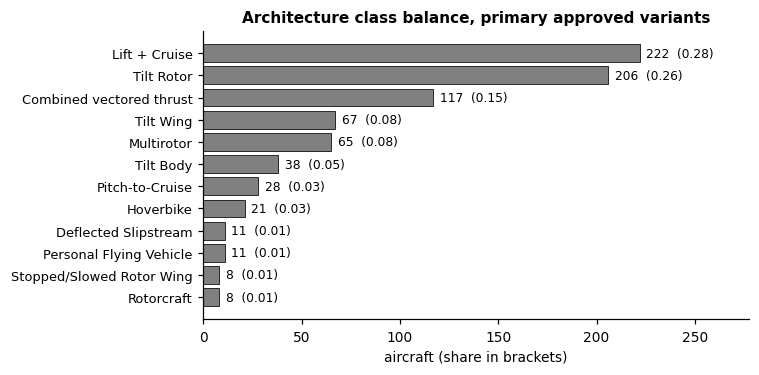

In [30]:
display(a2.d3_architecture_balance(ds))
_ = figures.class_balance_bars(a2.d3_architecture_balance(ds))

### 5.5 Class shares per window

- **Source**: D9 window table.
- **Tables / figures**: window × variants × share of TR / SLC / CVT / MR; stacked-area figure with the partial window hatched.
- **Gives →** a first look at a shift from tilt rotor to lift plus cruise, and no class above about a third in any window, so raw shares show no dominant design. This is the pattern Ch. 5 tests, not assumes. Feeds: Ch. 5 window definition and hypotheses.

,window,variants,Tilt Rotor,Lift + Cruise,Combined vectored thrust,Multirotor
0,<= 2011,87,0.34,0.22,0.15,0.11
1,2012-15,94,0.31,0.27,0.13,0.04
2,2016-19,284,0.24,0.23,0.14,0.10
3,2020-23,276,0.24,0.33,0.16,0.06
4,2024-26 (partial),64,0.22,0.34,0.14,0.08


largest share of any class in any window: 0.34


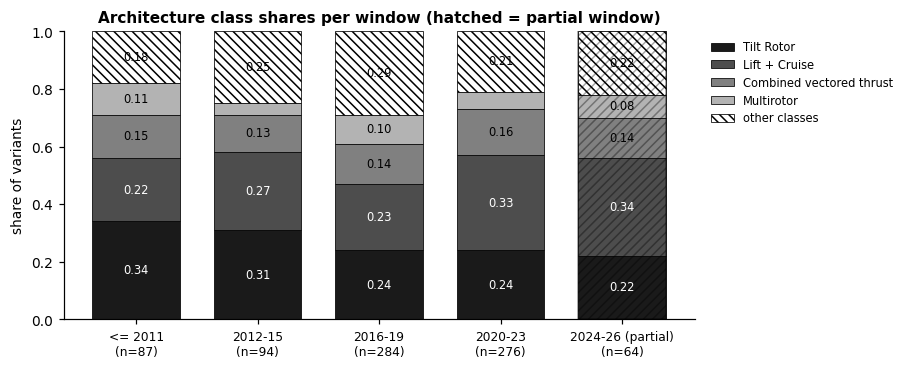

In [31]:
windows = a2.d9_architecture_by_window(ds)
display(windows)
print('largest share of any class in any window:',
      round(windows.attrs['max_share_any_class_any_window'], 2))
_ = figures.class_share_stacked_area(windows)

---
## Additions worth considering

### A.6 Named-aircraft state (A.5)

- **Source**: A.5 (addition 6).
- **Tables / figures**: name proposals by source; what is reviewed and where.
- **Gives →** proposals exist but none is verified; company-attributed names are statements about the assignee, not the drawing. One short table if the named-aircraft stratum stays in RQ3; otherwise a sentence in 3.2.

In [32]:
proposals = a5.name_proposals(ds)
display(proposals)
print(proposals.attrs)
display(a5.gazetteer_by_company(ds))
a5.review_sets(ds)

,value,count,share,name appears in the patent's own text
0,gazetteer,351,0.91,No 351
1,sbert,36,0.09,Yes 36


{'proposals': 387, 'no_proposal': 1252}


,company_canonical,aircraft_name,patents
0,Bell / Textron,APT,69
1,Honda,Honda eVTOL,37
2,Lilium,Lilium Jet,29
3,Kitty Hawk,Flyer,22
4,Wofei / Geely Aviation,AE200,20
5,Joby Aviation,S4,20
6,Beta Technologies,Alia-250,16
7,Aurora Flight Sciences,Passenger Air Vehicle,14
8,Hyundai,S-A1,14
9,Boeing,Passenger Air Vehicle,14


,set,rows,decision
0,SBERT text hits,36,keep / clear; recommendation: clear all of them
1,"Company-attributed, per company",29,"accept the attribution rule for the company, review its 351 patents one by one, or clear"
2,03a name queue,93,(no name) 74 · sbert 17 · gazetteer 2


### Not in the preliminary analysis (by design)

Image-vs-text agreement (κ 0.61), Hill numbers, Rao's Q, MCA, permutation tests, kNN communities. These are results of Ch. 4–7, and the preliminary analysis only has to hand them a fixed dataset, a field shortlist, an archetype level, a window definition and a sensitivity-flag list.

---
## Export — tables, figures, the roster and the draft document

`outputs/preliminary_analysis/` gets every table as CSV and markdown (`tables/`), every figure as
PNG (`figs/`), and `PRELIMINARY_ANALYSIS.md`: the index text with the live tables and figures in
place. Edit the prose there; never the numbers. Render with
`python3 scripts/build_styled_md_pdf.py <md> <pdf>` from the repo root.

In [33]:
TABLES = export.build_all(ds, F['rule_decisions_glob'], PARTIAL)
FIGS = figures.render_all(ds, OUT, PARTIAL)
plt.close('all')
written = export.write_all(TABLES, OUT)
draft = report.write_markdown(ds, TABLES, FIGS, OUT)
print(f'{len(written)} tables, {len(FIGS)} figures -> {OUT}')
print('draft:', draft, f'{draft.stat().st_size / 1024:.0f} KB')

70 tables, 10 figures -> /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/eVTOL-Visual-Evaluation/labeling_evaluation/outputs/preliminary_analysis
draft: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/eVTOL-Visual-Evaluation/labeling_evaluation/outputs/preliminary_analysis/PRELIMINARY_ANALYSIS.md 64 KB


---
## Appendix — the framework-document sections the index excludes

Kept here because they are measured on the same data and because `published.check` (the drift
check of every number the framework document prints) depends on them. They are results of
Ch. 4–7, not of the preliminary analysis.

### A.4 Architecture from the text, and its confirmation

In [34]:
display(a4.what_was_done(ds))
display(a4.agreement_with_images(ds))
display(a4.agreement_by_type(ds))
display(a4.disagreements(ds))
a4.confusion_matrix(ds)

,the reading pass,patents
0,Approved primary patents read from text only,695
1,Patents whose text states an architecture,632
2,"Patents whose text does not (component patents, control methods, design patents)",63
3,Patents drawing a single architecture,677
4,Patents drawing more than one architecture,18


{'n': 611,
 'agreement': 0.684,
 'kappa': 0.61,
 'single_type_patents_stating_a_type': 614,
 'without_an_image_label': 3,
 'high_n': 365,
 'high_agreement': 0.79,
 'medium_n': 225,
 'medium_agreement': 0.54,
 'low_n': 24,
 'low_agreement': 0.33,
 'multi_type_patents': 18,
 'text_type_is_among_the_drawn': 0.72}

,image_label,name,aircraft,recovered
0,TR,Tilt Rotor,162,0.87
1,RC,Rotorcraft,7,0.86
2,TB,Tilt Body,34,0.82
3,SLC,Lift + Cruise,156,0.74
4,SRW,Stopped/Slowed Rotor Wing,7,0.71
5,TW,Tilt Wing,57,0.70
6,CVT,Combined vectored thrust,95,0.57
7,MR,Multirotor,41,0.49
8,DS,Deflected Slipstream,10,0.40
9,HB,Hoverbike,17,0.18


,image reads,text reads,image_label,text_label,patents
0,Combined vectored thrust,Tilt Rotor,CVT,TR,22
1,Lift + Cruise,Combined vectored thrust,SLC,CVT,15
2,Tilt Rotor,Combined vectored thrust,TR,CVT,11
3,Combined vectored thrust,Lift + Cruise,CVT,SLC,9
4,Pitch-to-Cruise,Lift + Cruise,PTC,SLC,9
5,Tilt Wing,Tilt Rotor,TW,TR,9
6,Hoverbike,Multirotor,HB,MR,8
7,Lift + Cruise,Stopped/Slowed Rotor Wing,SLC,SRW,7
8,Lift + Cruise,Multirotor,SLC,MR,7
9,Lift + Cruise,Rotorcraft,SLC,RC,7


text_label,CVT,DS,HB,MR,PTC,RC,SLC,SRW,TB,TR,TW
image_label,,,,,,,,,,,
CVT,54,1,0,0,2,0,9,2,1,22,4
DS,1,4,0,0,0,0,0,0,1,4,0
HB,1,0,3,8,0,0,1,0,1,2,1
MR,2,0,0,20,0,4,4,2,2,4,3
PFV,0,0,0,4,0,0,0,0,1,1,1
PTC,1,0,0,4,2,0,9,0,0,2,0
RC,1,0,0,0,0,6,0,0,0,0,0
SLC,15,0,0,7,2,7,115,7,1,2,0
SRW,0,0,0,0,0,2,0,5,0,0,0


In [35]:
protocol = a4.confirmation_protocol(ds)
display(protocol)
print(protocol.attrs)
display(a4.citation_quality(ds))
display(a4.known_aircraft_list(ds).head(10))
multi = a4.multi_aircraft_patents(ds)
display(multi)
print(multi.attrs)
a4.final_state(ds)

,what they are,rows,what happens
0,"three independent sources agree: the figure label, the text reading (or its silence) a...",27,"cleared automatically, provenance known_aircraft"
1,"text and image agree, citation shown",399,the annotator reads the citation and confirms the type
2,"agree, but the text reading was low-confidence",8,"same, read more carefully"
3,text != image,201,the annotator adjudicates
4,text does not state an architecture; no citation exists,60,no decision; the image label stands with provenance not_stated


{'screen_work': 608, 'read_and_confirm': 407}


,kind,value,count,share
0,verbatim check,verbatim,553,0.80
1,verbatim check,partial,74,0.11
2,verbatim check,NS,63,0.09
3,verbatim check,not_found,5,0.01
4,section the citation comes from,abstract,230,0.37
5,section the citation comes from,claim 1,95,0.15
6,section the citation comes from,description,71,0.11
7,section the citation comes from,mixed,231,0.36


,company,models,aircraft,types,architectures differ
0,Airbus,2,CityAirbus · CityAirbus NextGen,MR · SLC,True
1,Bell / Textron,2,APT · Nexus,TB · TR,True
2,Kitty Hawk,2,Flyer · Heaviside,MR · TR,True
3,Wisk Aero,2,Generation 6 · Cora,CVT · SLC,True
4,Archer Aviation,2,Midnight · Maker,CVT,False
5,AMSL Innovations,1,Vertiia,TR,False
6,Ascendance Flight Technologies,1,ATEA,SLC,False
7,Aurora Flight Sciences,1,Passenger Air Vehicle,SLC,False
8,Beta Technologies,1,Alia-250,SLC,False
9,Boeing,1,Passenger Air Vehicle,SLC,False


,case,patents,how the comparison is made
0,"Several aircraft, all of the same architecture",50,treated as a single-type patent; the text label is compared with that type
1,Several aircraft of genuinely different architectures,18,"the text type is among the patent's image types (13 of 18), or none of them (5)"


{'patents_with_several_aircraft': 68, 'variants_they_contribute': 178}


,value,count,share
0,pending,608,0.87
1,not_stated,60,0.09
2,known_aircraft,27,0.04


### A.6 The identity variables: what the patents themselves say

In [36]:
display(a6.evidence_per_variable(ds))
display(a6.powertrain_without_evidence(ds))
outcome = a6.reading_outcome(ds)
display(outcome)
print(outcome.attrs)
display(a6.powertrain_vocabulary(ds))
display(a6.contradiction_summary(ds))
display(a6.contradictions(ds))
a6.gazetteer_ambiguous_companies(ds).head(10)

,variable,with a citation,of,without
0,take-off mode,677,695,18
1,powertrain,477,695,218
2,UAV hint,56,695,639
3,aircraft name,17,695,678


,value,count,share
0,gazetteer,114,0.52
1,presumed,101,0.46
2,company,3,0.01


,outcome,patents,meaning
0,The text settles the powertrain,100,a citation now exists where none did
1,- of which it confirms the 03a verdict,63,the verdict was right
2,- of which it contradicts the 03a verdict,37,listed by :func:`contradictions`
3,The text never says what powers the aircraft,137,"a finding, not a gap"
4,- of which Alternatives (several powertrains offered),26,the patent commits to none
5,- of which nothing at all,111,


{'patents_read': 237}


,value,count,share
0,NotStated,111,0.47
1,BatteryElectric,80,0.34
2,Alternatives,26,0.11
3,HybridElectric,13,0.05
4,Turbine,6,0.03
5,Piston,1,0.00


,03a says,the text says,patents
0,Unknown,Yes,18
1,Yes,Hybrid,8
2,Hybrid,Yes,6
3,Yes,No,4
4,Unknown,No,1


,patent_id,company_canonical,03a says,is_electric_source,the text says,powertrain read,citation
0,US2017203839A1,Aurora Flight Sciences,Yes,gazetteer,Hybrid,HybridElectric,a turbo shaft engine that drives one or more generators through a gearbox. The generat...
1,US2021309351A1,Aurora Flight Sciences,Yes,gazetteer,Hybrid,HybridElectric,an engine; an electric motor; a first propeller driven by the engine; a second propell...
2,US2018354615A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes redundant internal combusti...
3,US2018362160A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,"power source 72 includes a battery 74, a generator 76, and a combustion engine 78"
4,US2019031333A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes redundant internal combusti...
5,US2019100313A1,Bell / Textron,Yes,gazetteer,Hybrid,HybridElectric,Electrical energy generation system 48 preferably includes one or more internal combus...
6,US2022126998A1,Hyundai,Yes,gazetteer,Hybrid,HybridElectric,a main thrust device including an engine and motors ... batteries configured to supply...
7,US2022144443A1,Hyundai,Yes,gazetteer,Hybrid,HybridElectric,A hybrid air mobility vehicle comprising: an engine and a generator; a battery and a d...
8,US2014263854A1,Bell / Textron,Unknown,presumed,No,Turbine,"an improved turbine burst capability from the engine systems 140, 142 by angling any t..."
9,US2017144746A1,Bell / Textron,Yes,gazetteer,No,Turbine,"engines 24a, 24b are operable in turboshaft mode wherein hot combustion gases in each ..."


,company_canonical,patents_read,readings,distinct_readings
0,Bell / Textron,18,NotStated 5 · Alternatives 5 · HybridElectric 4 · BatteryElectric 2 · Turbine 1 · Pist...,6
1,Kitty Hawk,10,BatteryElectric 8 · NotStated 2,2
2,Boeing,9,BatteryElectric 3 · NotStated 3 · Alternatives 2 · Turbine 1,4
3,Honda,8,BatteryElectric 6 · HybridElectric 2,2
4,Joby Aviation,8,BatteryElectric 8,1
5,Aurora Flight Sciences,8,NotStated 3 · Alternatives 2 · HybridElectric 2 · BatteryElectric 1,4
6,Lilium,6,BatteryElectric 6,1
7,Wisk Aero,5,BatteryElectric 5,1
8,Hyundai,5,HybridElectric 2 · BatteryElectric 2 · NotStated 1,3
9,Embraer / Eve,4,NotStated 2 · BatteryElectric 2,2


### A.1 Where each information source stands (framework table)

In [37]:
a1.source_state_table(ds)

,source,exists,state,verdict
0,"Image labels G1-M3 (wizard, 5 batches)",Yes,"1,639 patents; 1,110 approved / 529 rejected; 805 primary approved variants; master 1,...",Ready. This is the dataset.
1,Electric or not (03a),"Yes, machine",Yes 876 · Unknown 464 · Hybrid 229 · No 70,Priority 1 - inclusion gate.
2,VTOL or STOL (03a),"Yes, machine",VTOL 1381 · V/STOL 195 · STOL 4 · blank 59; quote for 1580,Priority 1. DECIDE what V/STOL means for inclusion.
3,Architecture from the TEXT (03a architecture_primary),"Yes, but a guess",agrees with the image label on 25.7% of 673 single-type approved patents (kappa 0.13);...,Not a gold standard. Superseded by the reading pass of A.4.
4,Scope (whole aircraft / subsystem / component),"Yes, machine",Architectural Subsystem Enabler 1371 · Whole Aircraft Architecture 258 · Component-Lev...,"Not a gate, and not derivable from the figure labels (1,891 of 1,913 approved figures ..."
5,Mission type (industry_primary),"Yes, weak","809 of 1,639 are General_Unspecified; the rest split over 9 industries",Park it.
6,"Specs (pax, MTOW, range, speed)",Almost empty,pax 10 · MTOW 1 · range 3 · cruise speed 3 non-empty,Out of scope - confirmed by the data.
7,Metadata (PatSeer via 03a),Yes,"priority_year for all 1,639; Granted 1,110 / Application 520; N. America 719 · Asia-Pa...",Ready.
8,Assignee type (company / university / individual),No,"not a column anywhere; suffix heuristic gives 1,029 company / 69 university / 541 unre...","Cheap to add, high value. Plan line G8."
9,Real aircraft name (03a),"Yes, proposals","387 proposals; aircraft_link Depicted 41 · CompanyAttributed 346 · empty 1,252; on the...",Only matters for a named-aircraft sub-analysis. Not a gate.


### Does the framework document still match the data?

`published.py` holds every number Part A of the framework document prints, next to the call that
recomputes it. A **drift** row means the dataset moved after the document was written, or that the
document's definition was wrong and the package uses the corrected one — read the note column.

In [38]:
check = published.check(ds, tolerance=F.get('tolerance', 0.006))
print(check['status'].str.split(':').str[0].value_counts().to_dict())
check[check['status'] != 'match']

{'match': 117, 'drift': 8}


,section,fact,published,live,status,note
6,A.1,electric: Yes,902.0,876.0,drift,measured before the burden-of-proof rewrite of the electric rule
7,A.1,electric: Hybrid,167.0,229.0,drift,same rewrite
8,A.1,electric: No,74.0,70.0,drift,same rewrite
35,A.2 D1,rejected: out of domain,159.0,158.0,drift,one rejected patent carries no reason at all (CN106494614A)
37,A.2 D2,distinct concepts,73.0,76.0,drift,the document's collapsing rule was not recorded; a2.concept_of is stated in code
70,A.2 D8,distinct raw filers,445.0,449.0,drift,03a was rebuilt after the document was written
71,A.2 D8,raw filers with exactly one patent,359.0,364.0,drift,same rebuild
84,A.3,aircraft with more than 8 propulsor units,121.0,133.0,drift,the document summed only the four main carriers; this counts every carrier


In [39]:
published.summary(ds)

state,section,drift,match
0,A.1,3,24
1,A.2 D1,1,8
2,A.2 D11,0,5
3,A.2 D2,1,8
4,A.2 D3,0,8
5,A.2 D4,0,3
6,A.2 D5,0,4
7,A.2 D6,0,3
8,A.2 D7,0,4
9,A.2 D8,2,6
